In [1]:
# Imports
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
from pandas import read_excel
import os
import glob

from Def_Analysis import LoadLicsbasTS, MaskNearbyVolcanoes, GetDispSteps, GetSignalPeaks, ClusterSignalPeaks, FindChangePoints
from Plot_Def_Analysis import PlotCumulativeDisplacement, PlotMaskingResults, PlotDispTimeSteps, PlotDetectedChanges

### Other files and params

In [2]:
# For masking volcanoes
Volcs_File = '/gws/ssde/j25a/nceo_geohazards/vol1/projects/COMET/DEEPVolc_Pedro/SCRIPTS_paper/Coherence_time_series/Volcanes_Chiles.txt'
GVP_Tab = '/work/xfc/vol7/user_cache/benirela/Other/GVP/GVP/GVP_Volcano_List_Holocene.xlsx'
GVP = read_excel(GVP_Tab)
TargBufferKm = 10
OtherBufferKm = 5
# Splitting up timeseries
T_WinsizeYrs = 1
binW_m = 0.001 # For SNR calculation
# Getting spatial peaks in signal
spatialRes_m = 60
min_radius_km = 3
SNRThresh = 3
# Cluster spatial peaks
eps_dist_km = 2
WS = 5
ClusterBufferKM = 1
# Detect change points
FiltSize = 10

### Filepaths

In [3]:
StorePath = '/work/xfc/vol7/user_cache/benirela/Other/Pedro_TS/'
EndPath = '/TS_GEOCml2clipmask/cum_filt.h5'
Volcanoes = ['Wolf','Alcedo','Cerro_Azul_Galapagos','Darwin','Fernandina','Sierra_Negra','Nabro','Asavyo','Dabbahu']
Frames = ['106A','106A','106A','128D','128D','128D','014A','014A','014A']

### Loop over all TS files and anaylse def stats.

Volcano number 1 out of 9


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


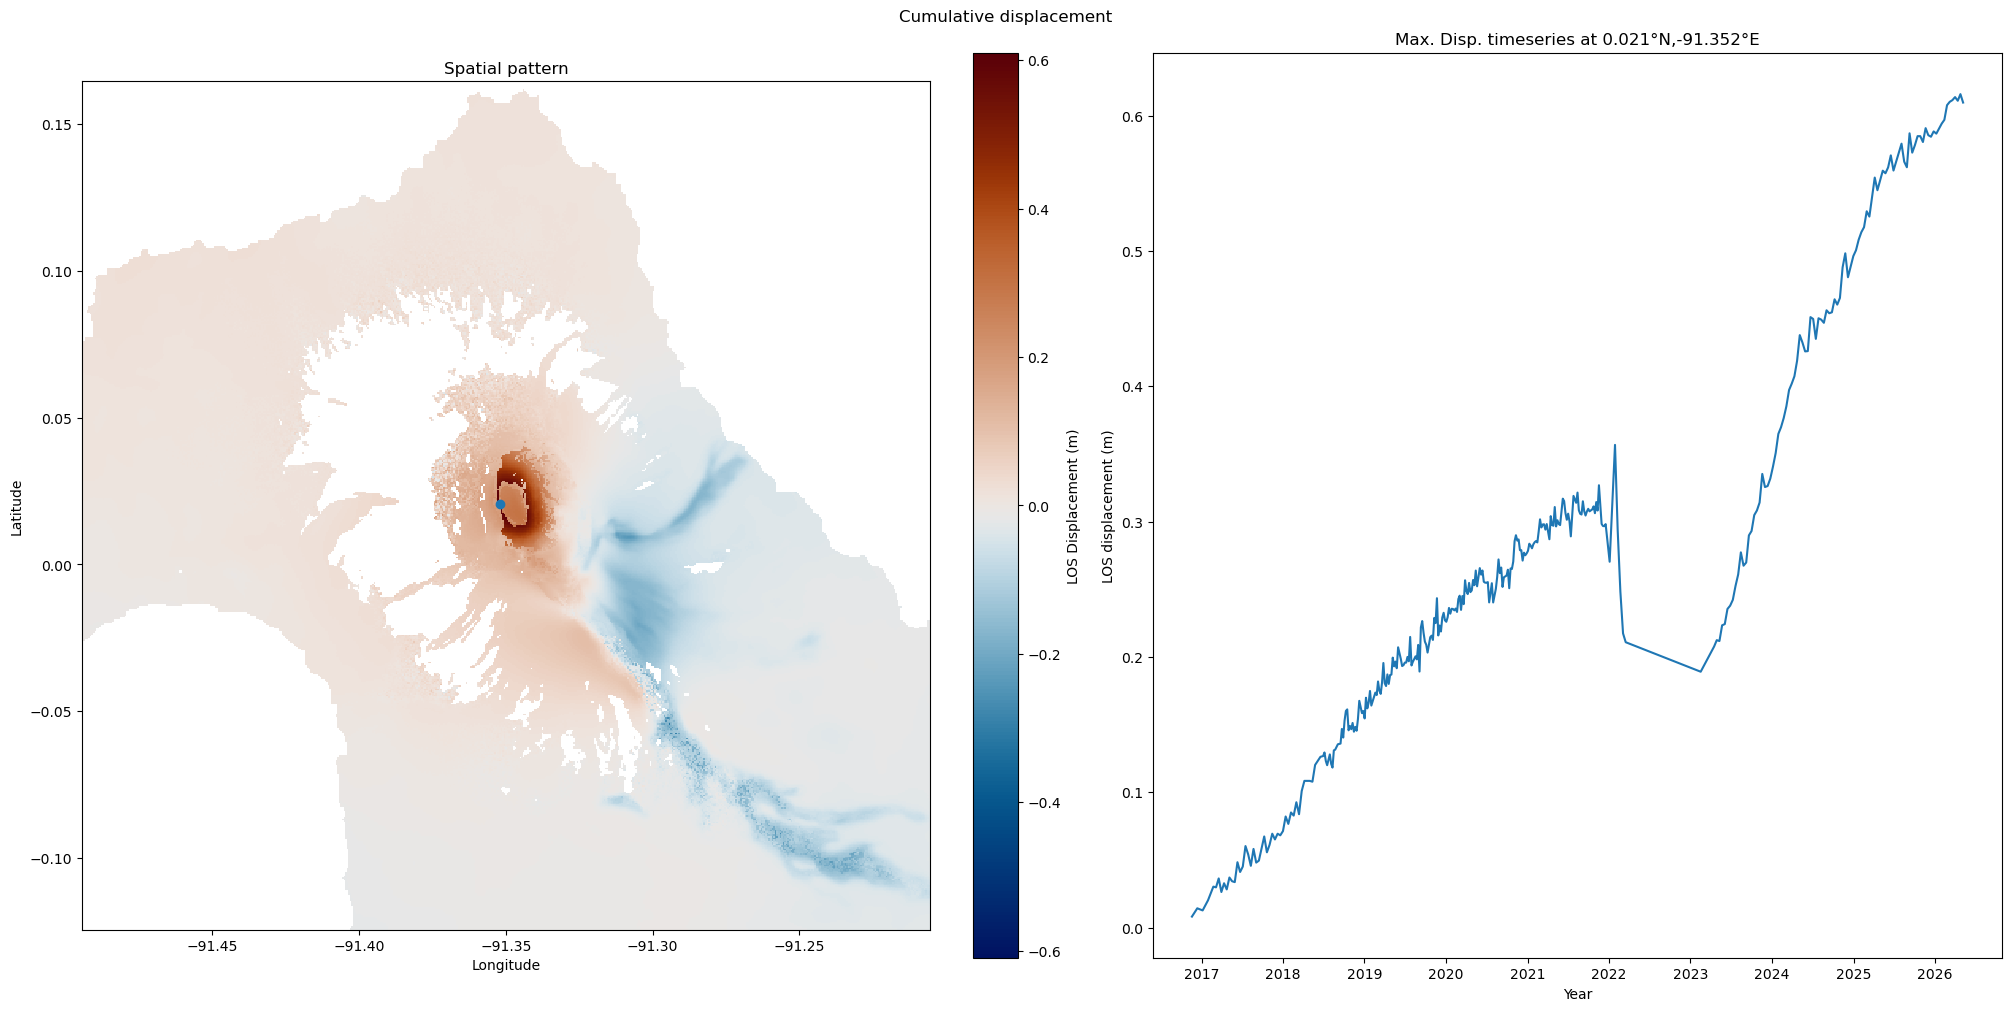

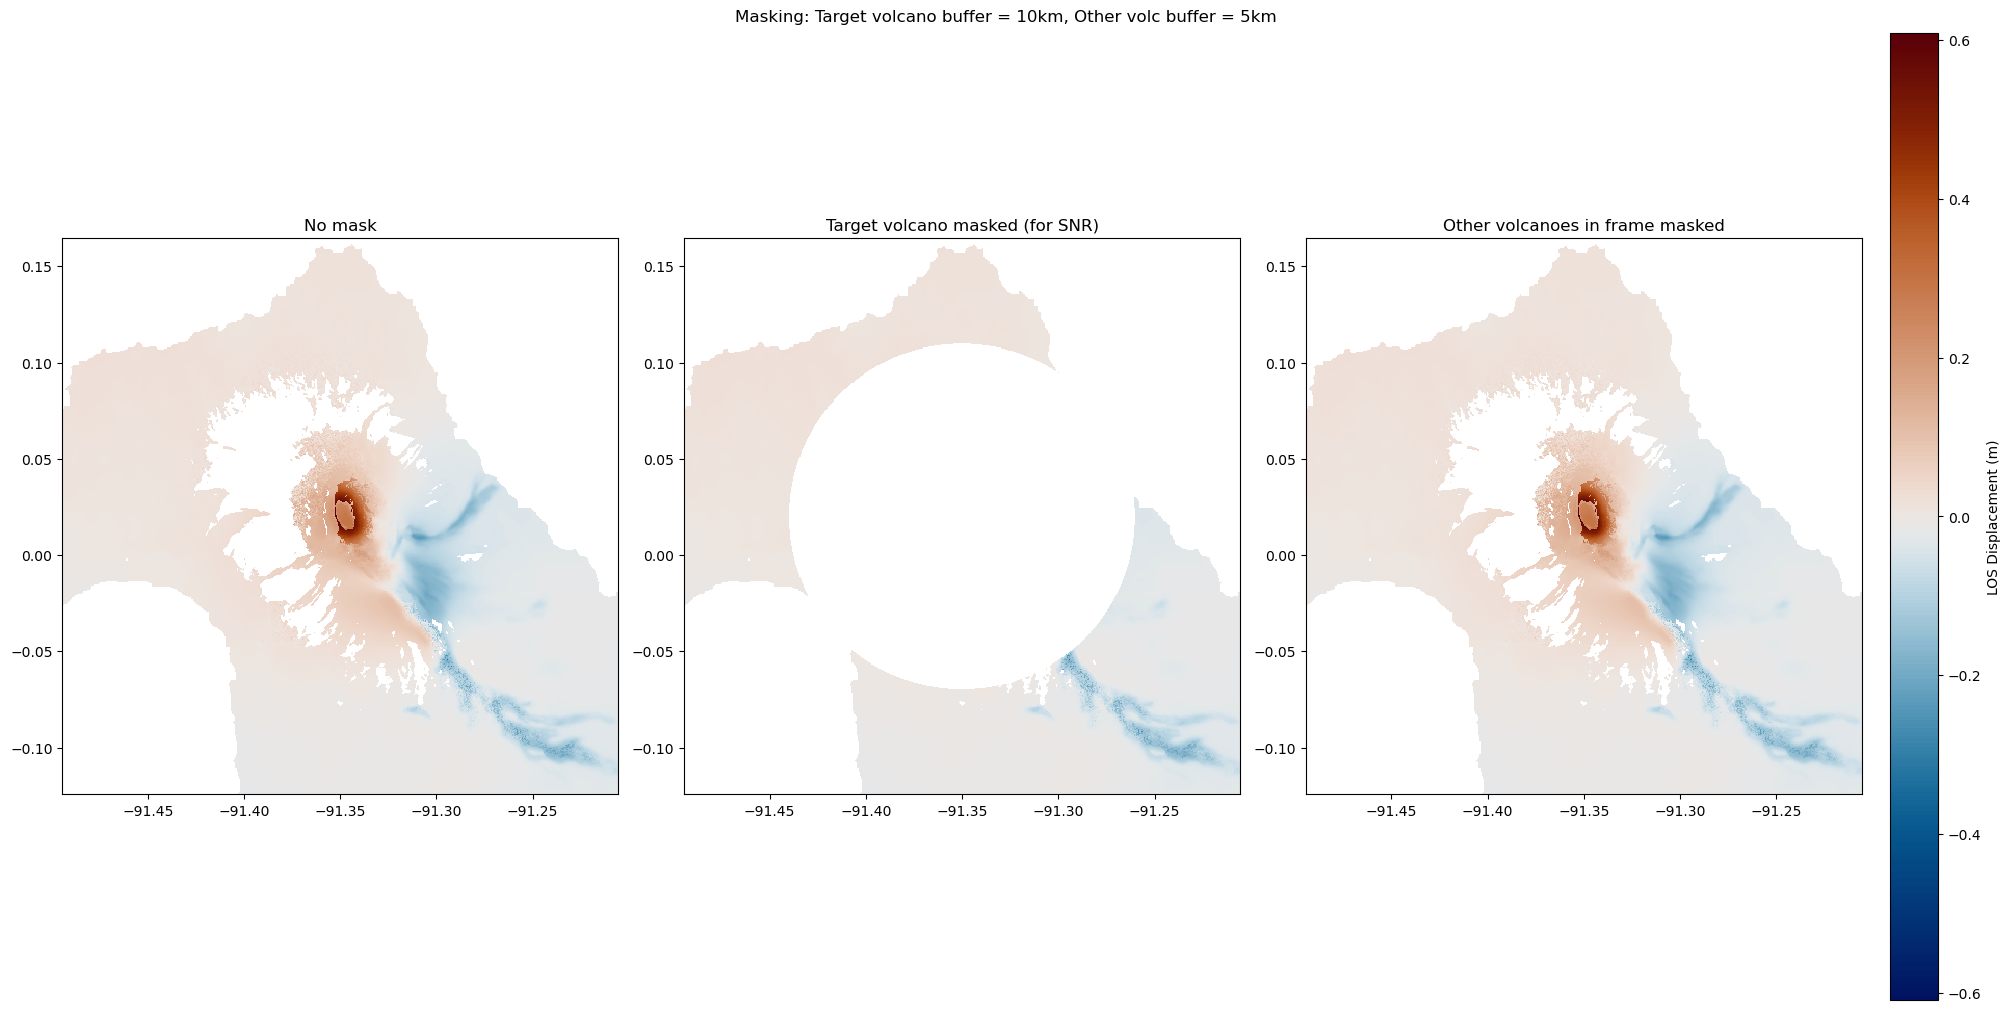

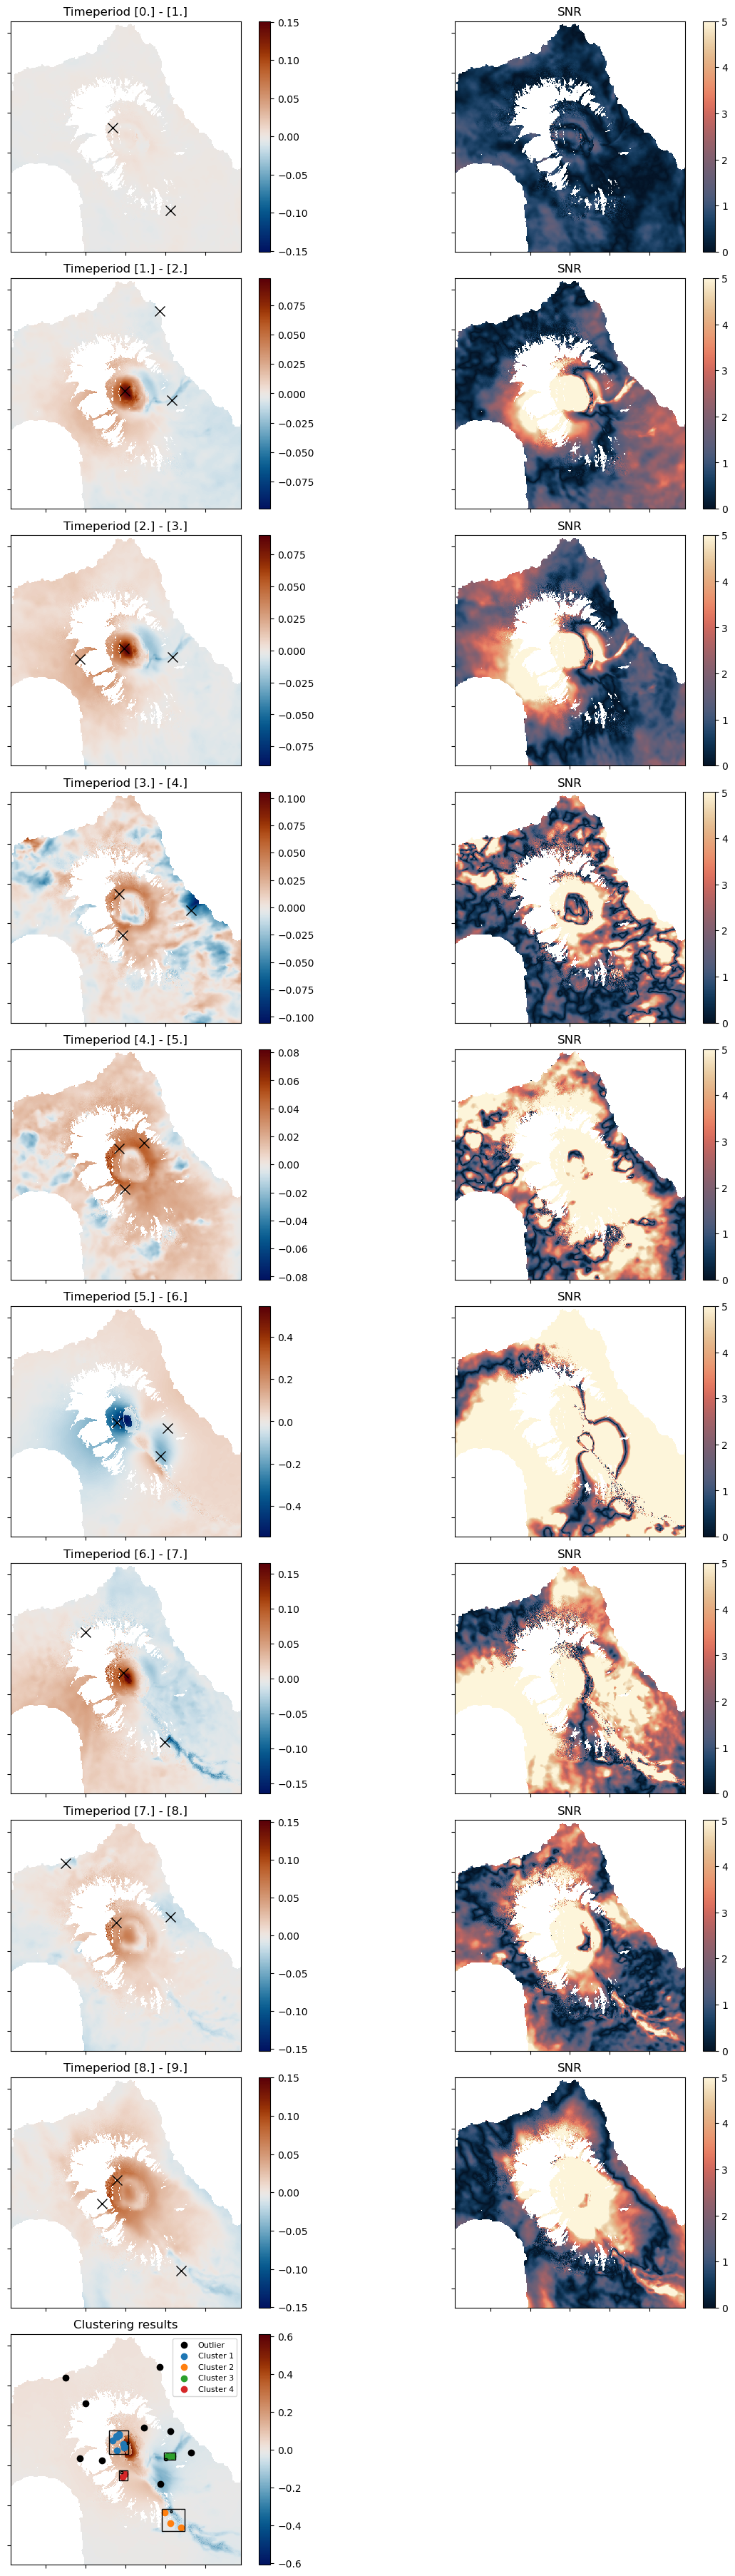

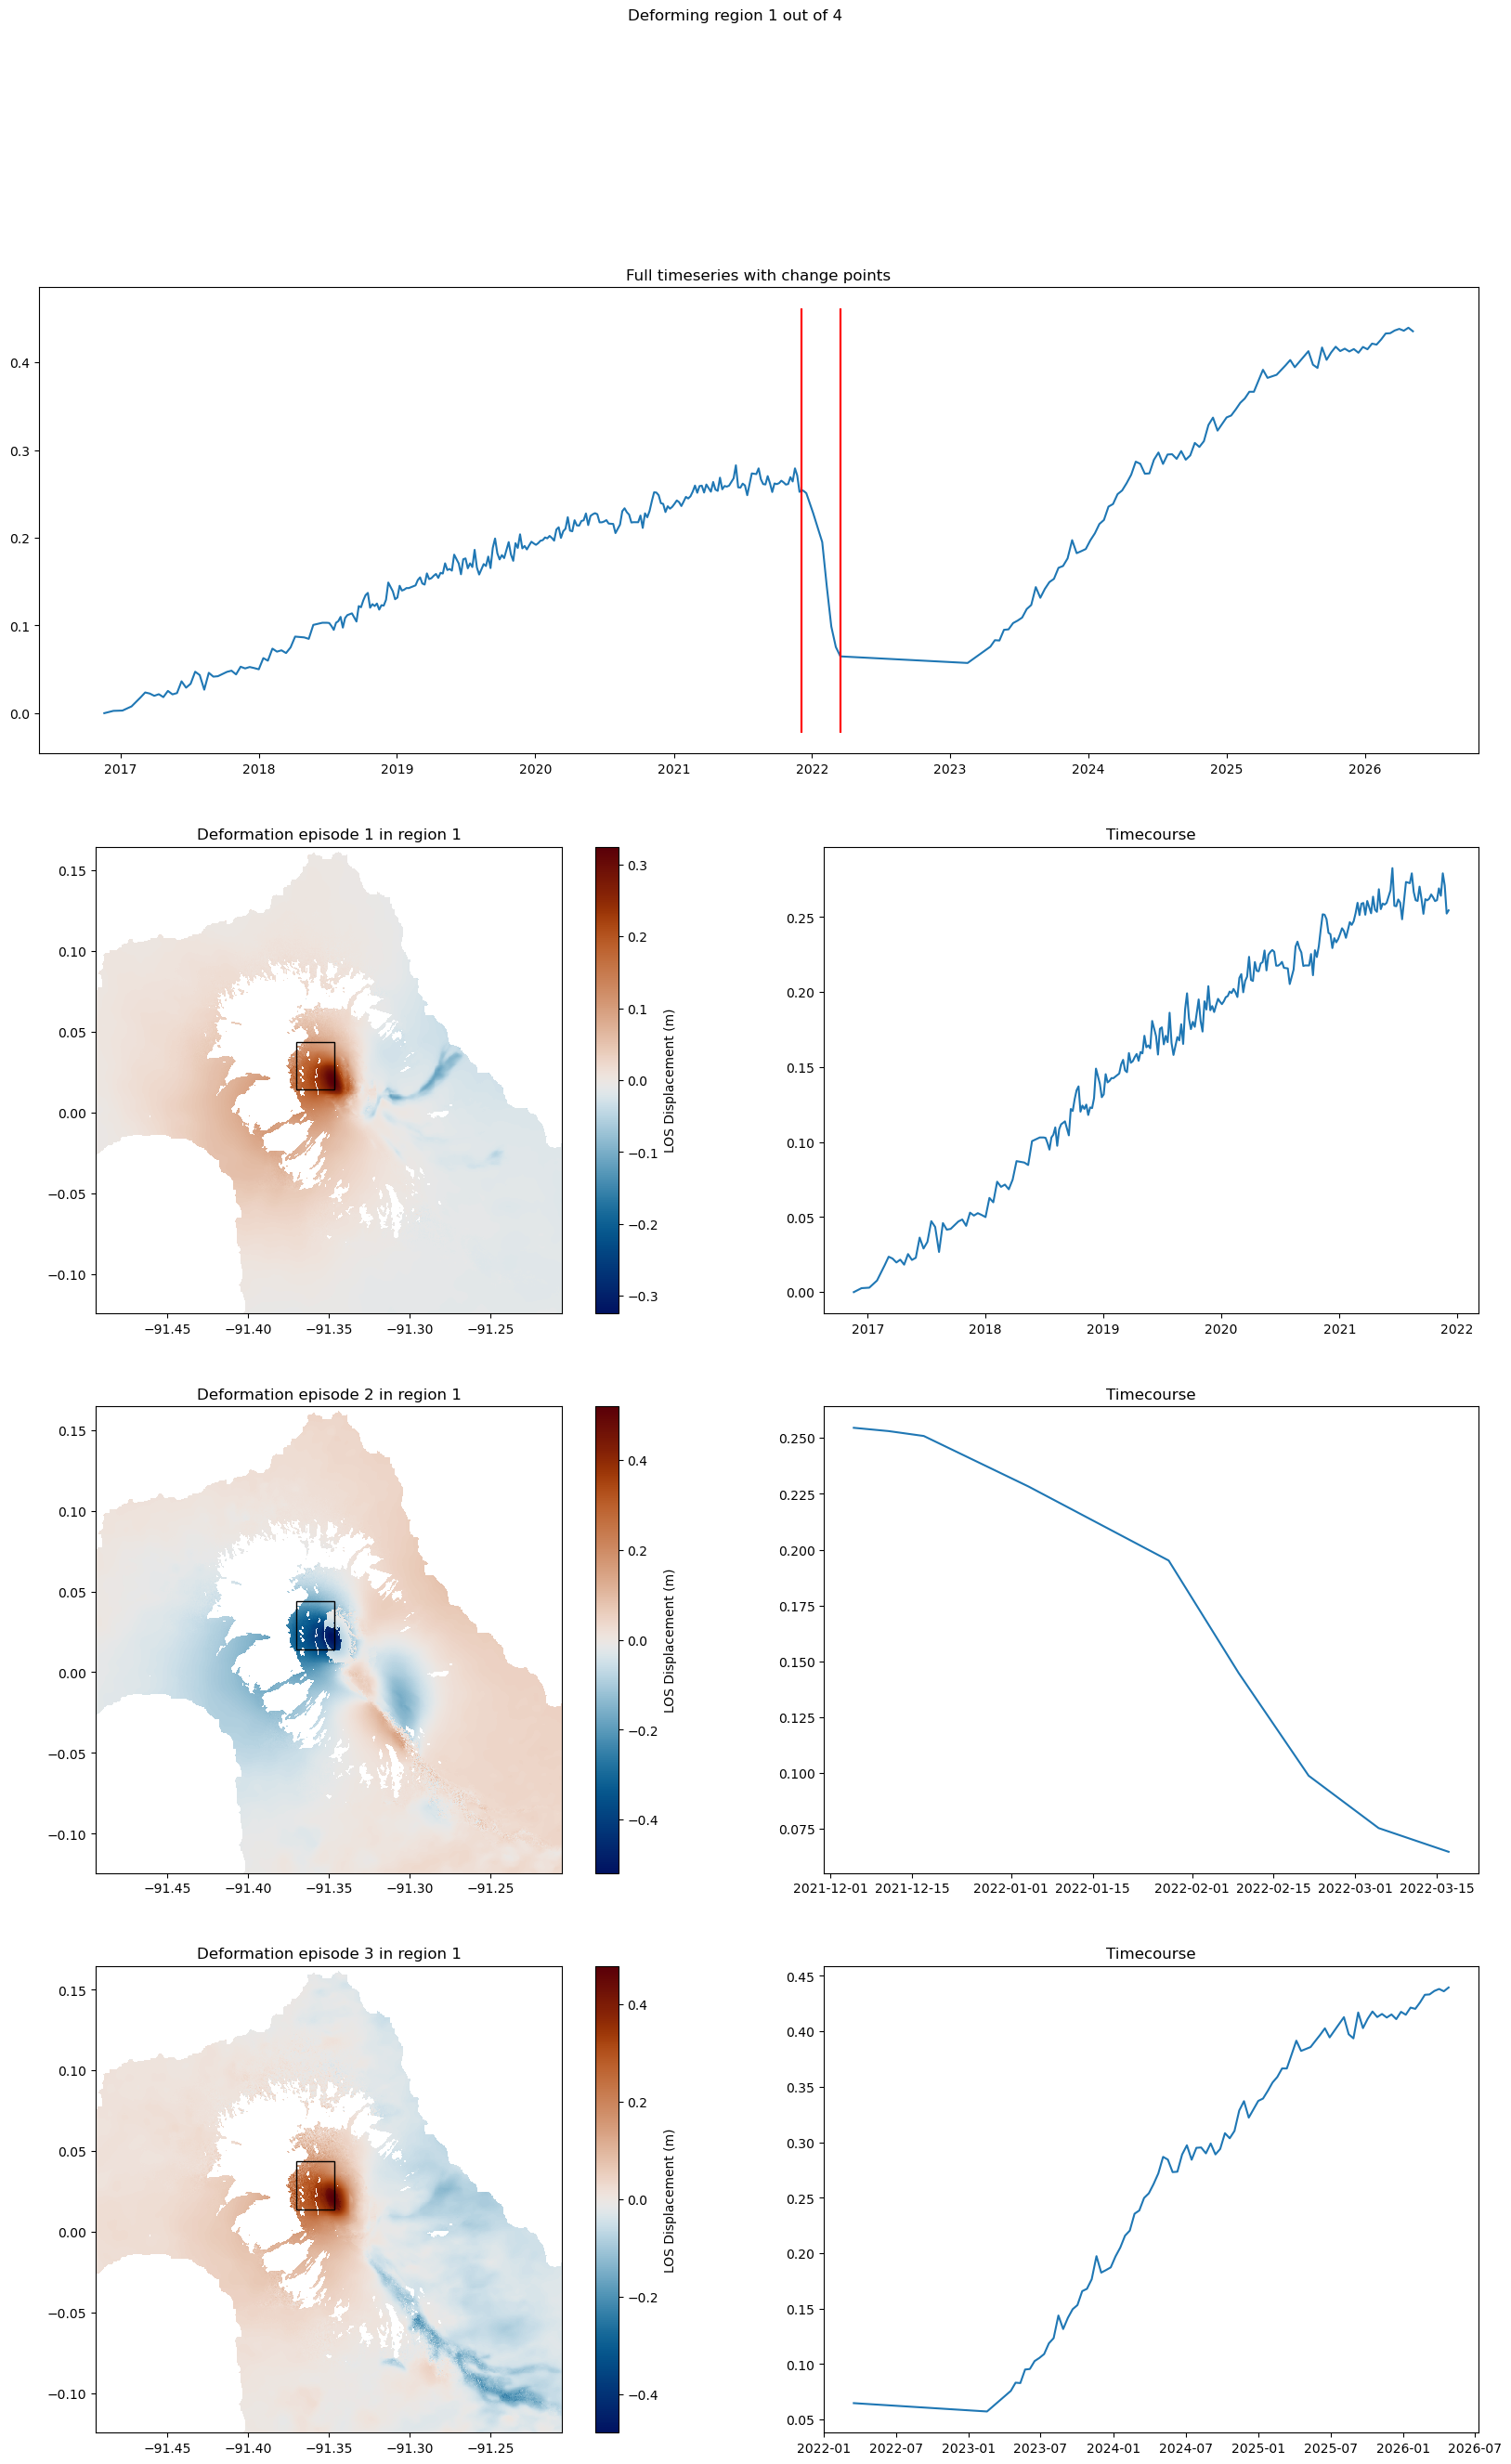

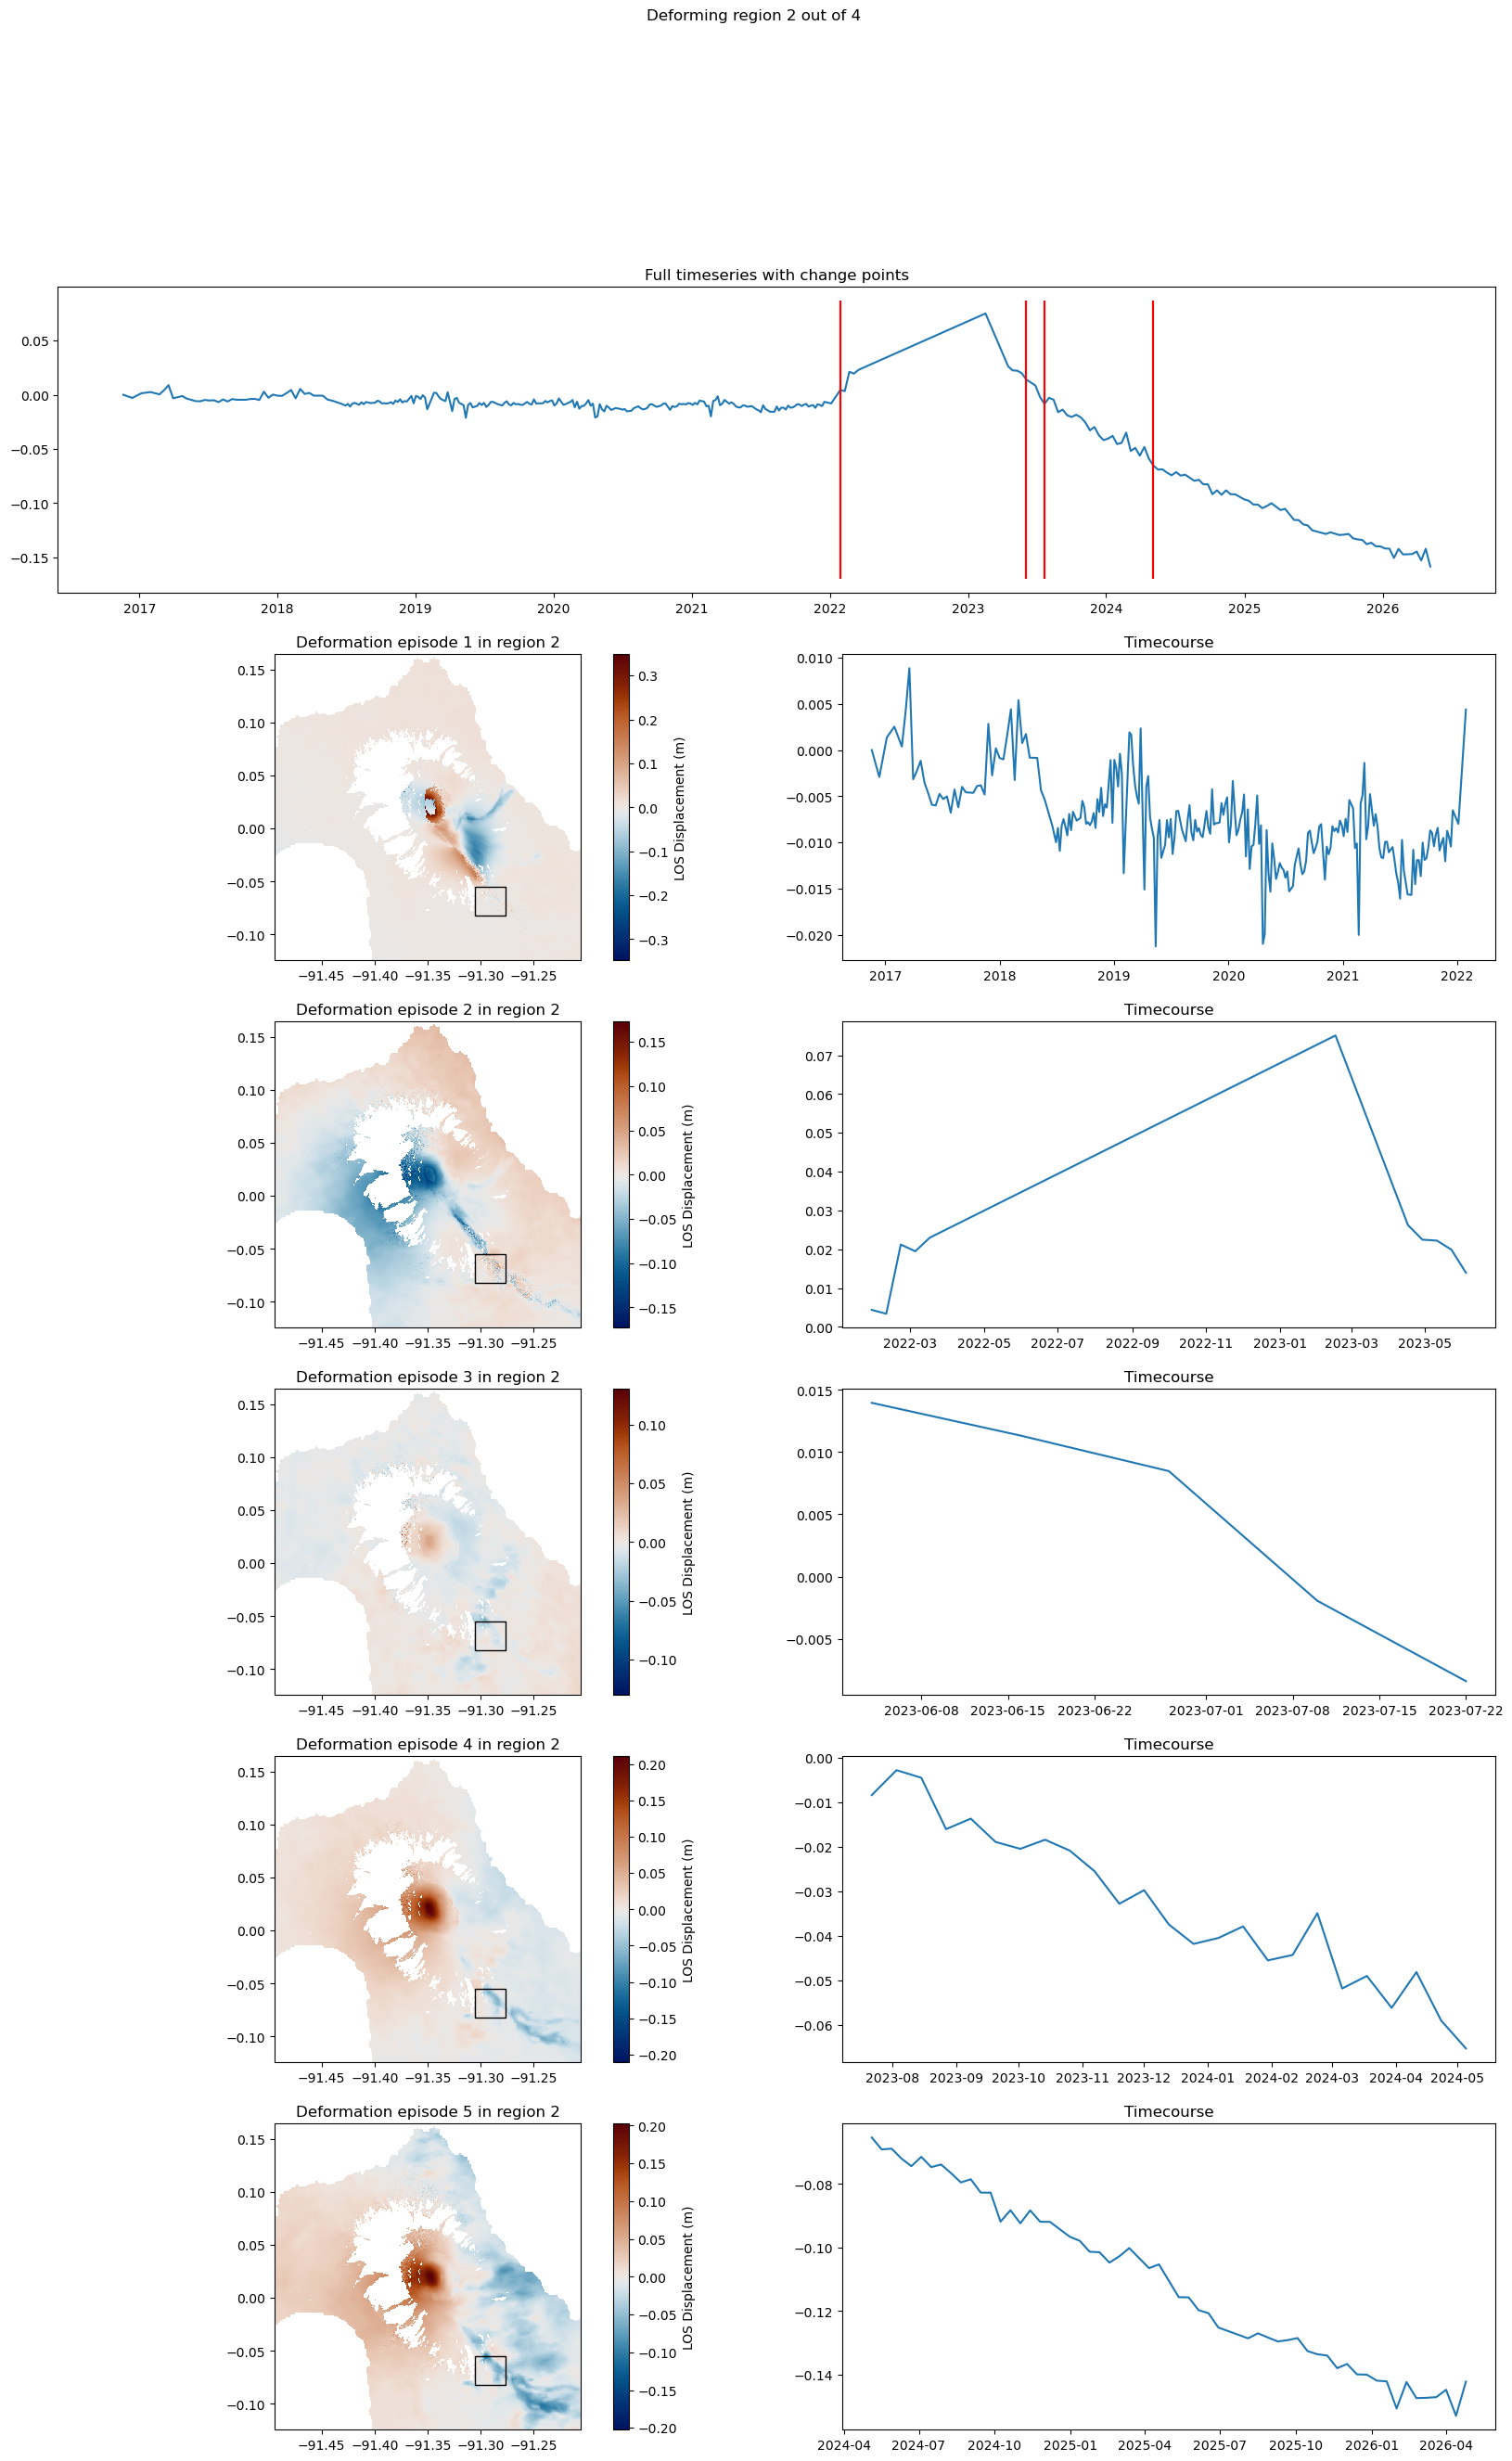

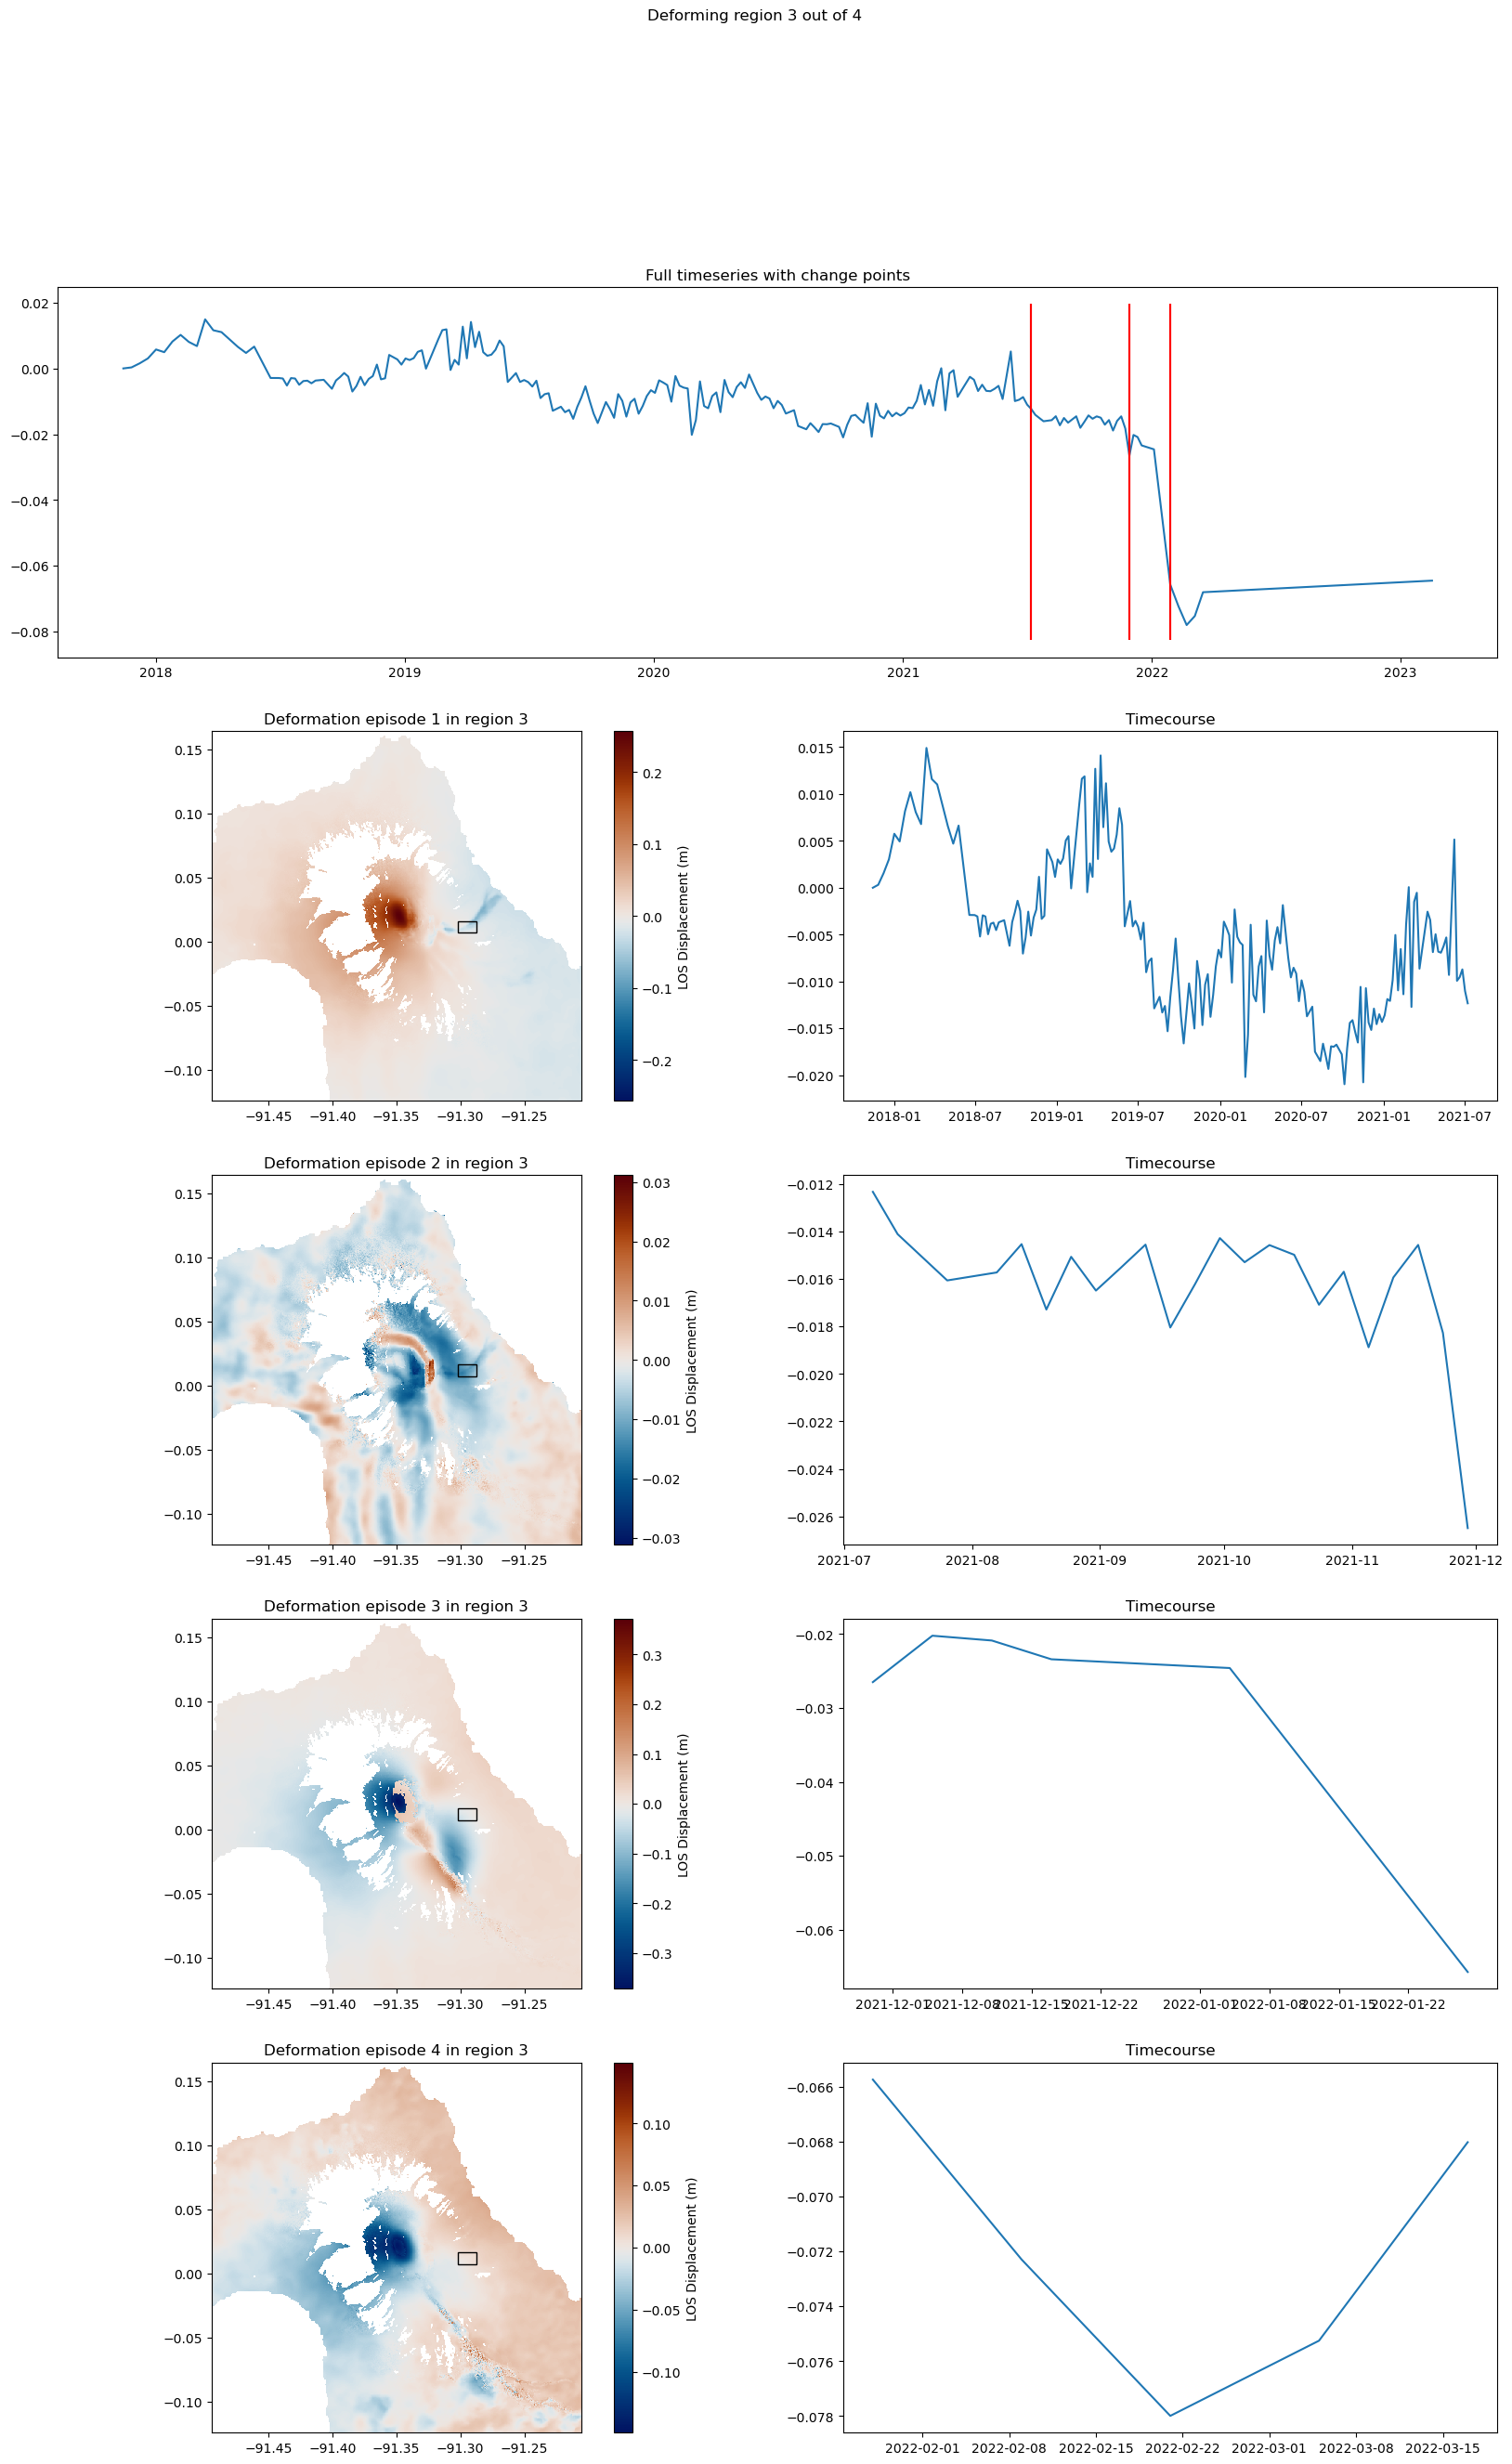

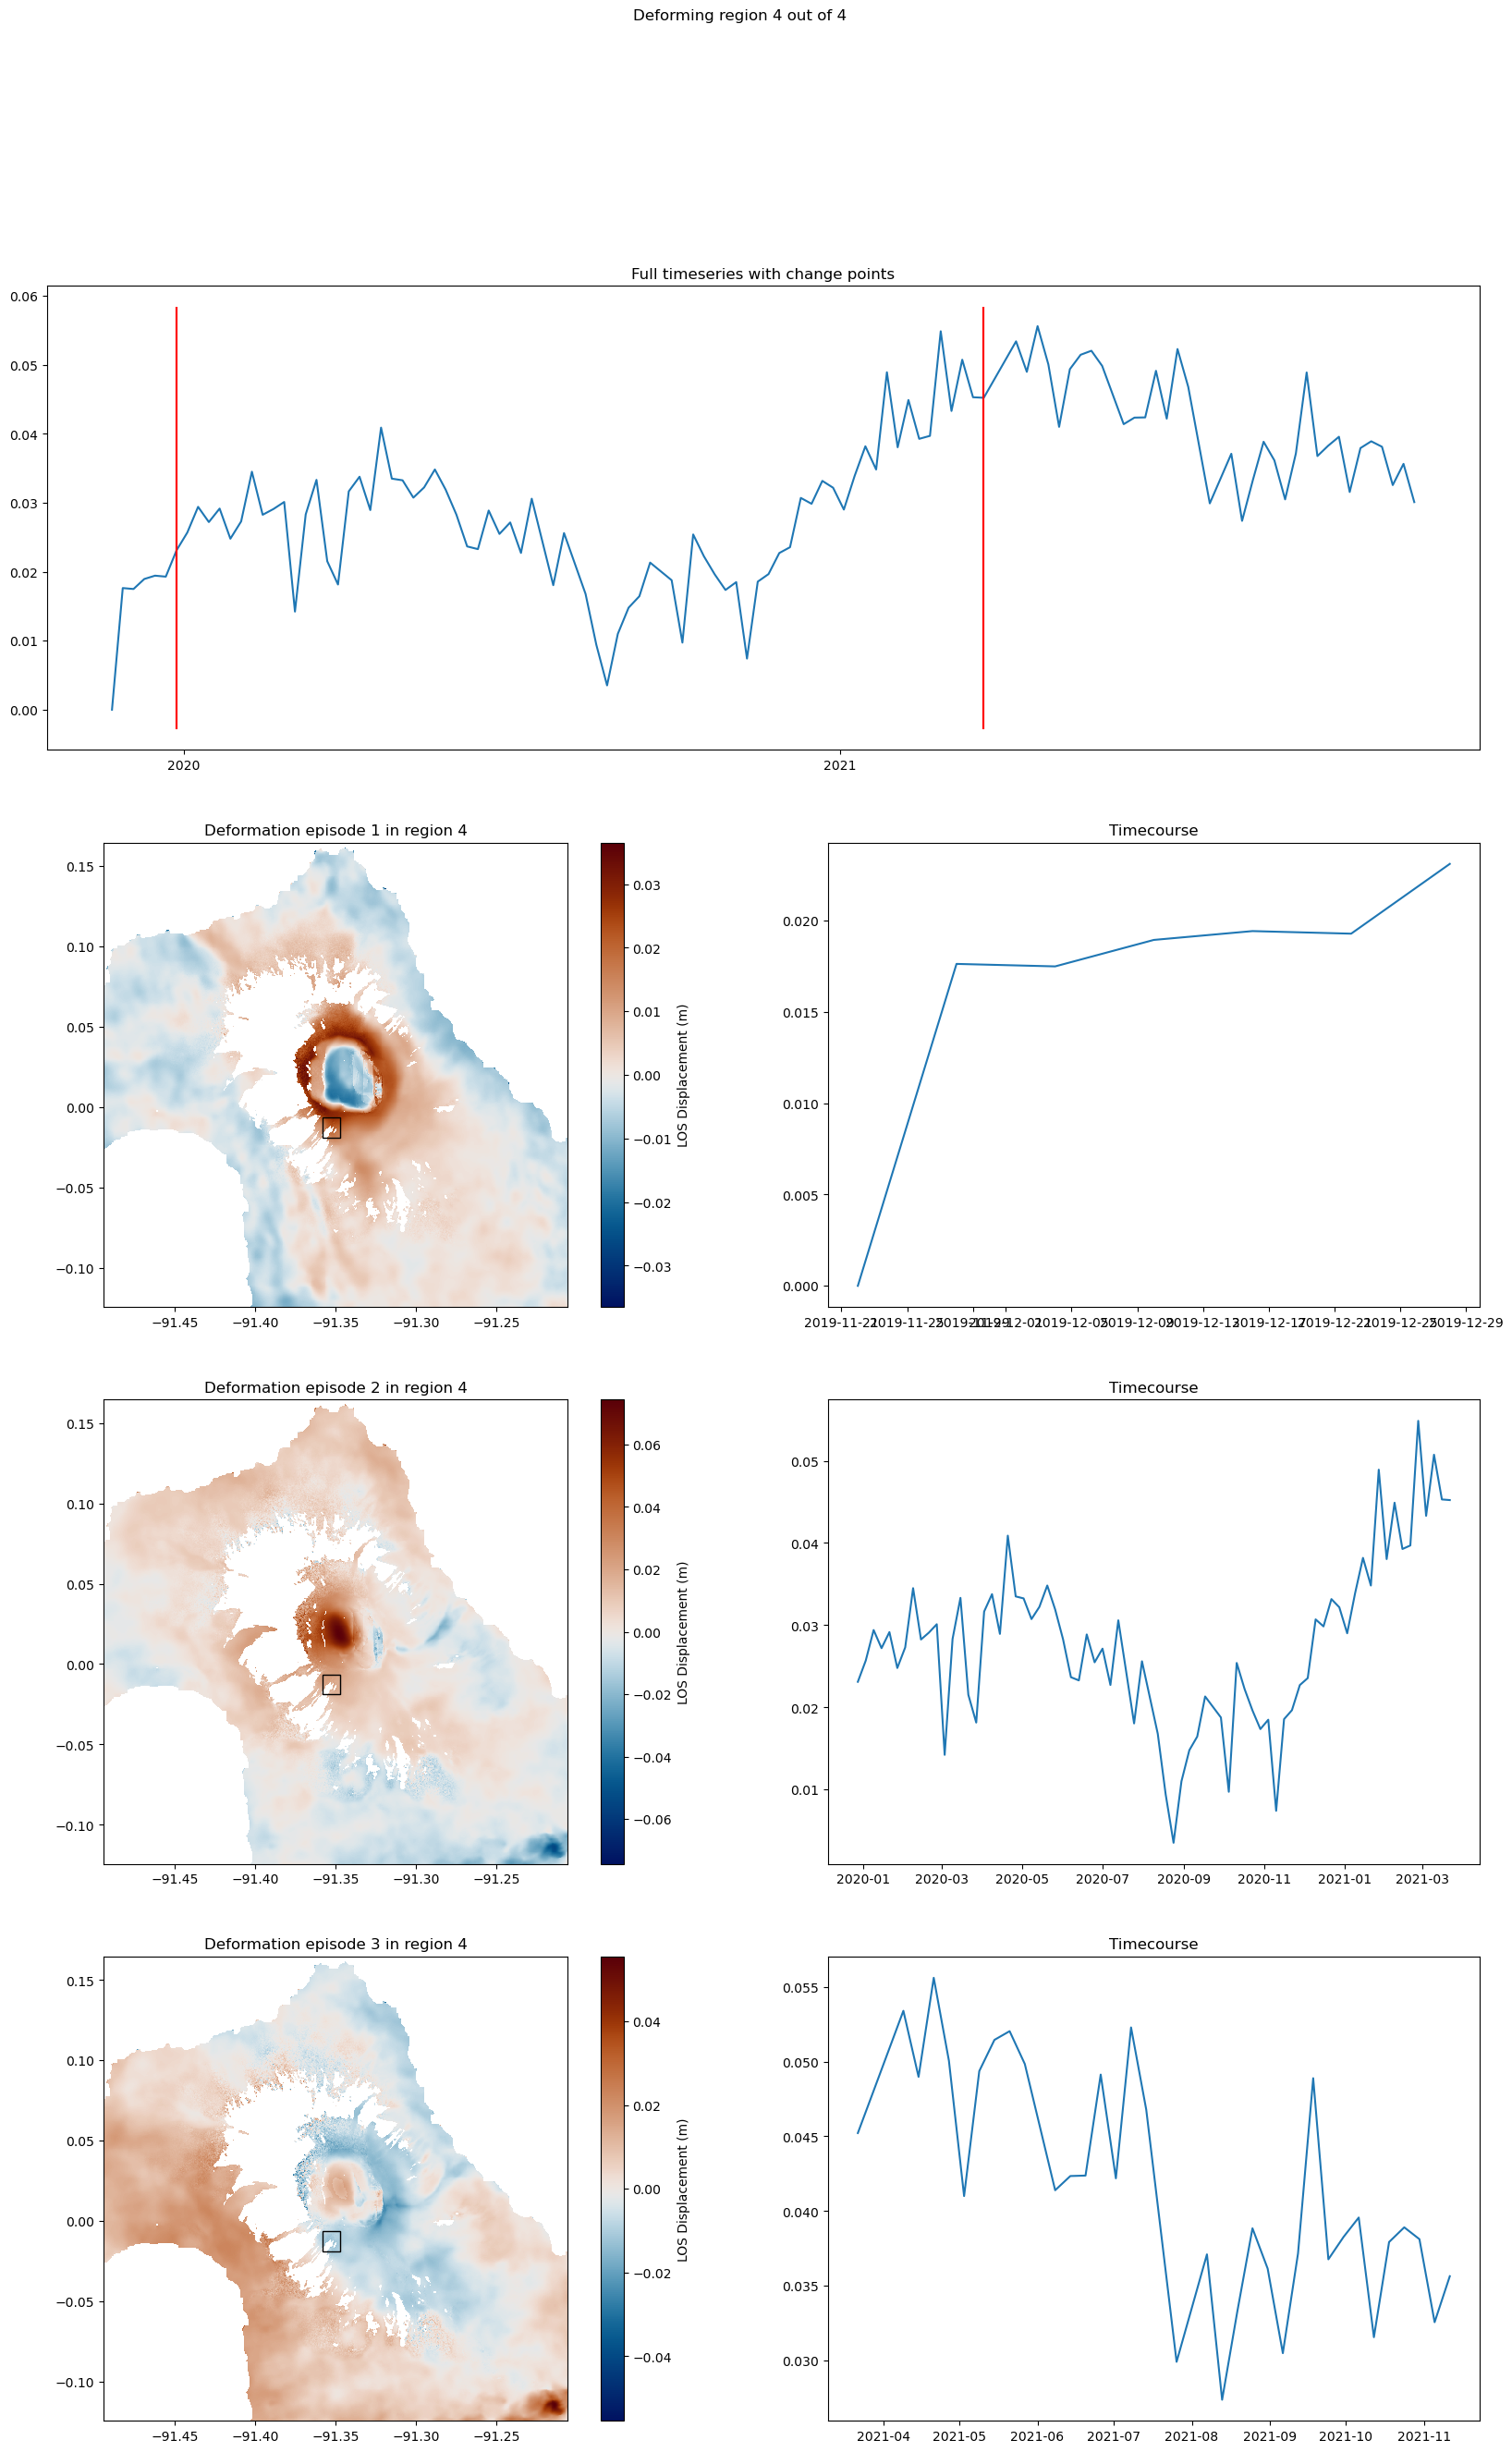

In [4]:
%autoreload 2
for i, (Volc, Frame) in enumerate(zip(Volcanoes,Frames)):
    print('Volcano number ' + str(i+1) + ' out of ' + str(len(Volcanoes)))
    TS_File = glob.glob(os.path.join(StorePath, Volc, Frame, 'TS_GEO*', 'cum_filt.h5'))
    TS_File = TS_File[0]

    # DO PROCESSING AND ANALYSIS
    LOS, Lon, Lat, days_, DatesDT = LoadLicsbasTS(TS_File)

    ForegroundMask, OtherVolcMask = MaskNearbyVolcanoes(GVP,Volcs_File,Lon,Lat,Volc,LOS,TargBufferKm,OtherBufferKm)

    Disp_Steps, Noise_Steps, SNR_Steps, StartYr, EndYr, yrsQ, idxYrs = GetDispSteps(days_,T_WinsizeYrs,LOS,ForegroundMask,binW_m)

    Peak_Coordinates, YrsFound = GetSignalPeaks(Disp_Steps,spatialRes_m,min_radius_km,SNRThresh,Noise_Steps,StartYr,EndYr)

    ChosenTS, ChosenTS_Days, ChosenTS_Yrs, DBSCAN_Clusts, Rect1Bounds, Rect2Bounds, StartEndIdx = ClusterSignalPeaks(Peak_Coordinates,eps_dist_km,spatialRes_m,WS,ClusterBufferKM,YrsFound,LOS,yrsQ,idxYrs,DatesDT,days_)

    Changes = FindChangePoints(ChosenTS, FiltSize,SNRThresh)

    # PLOT RESULTS

    CumDispFig = PlotCumulativeDisplacement(Lat,Lon,LOS,DatesDT)
    MaskingFig = PlotMaskingResults(Lat,Lon,LOS,ForegroundMask,OtherVolcMask,TargBufferKm,OtherBufferKm)
    TimestepsFig = PlotDispTimeSteps(Lat,Lon,Disp_Steps,LOS,Noise_Steps,StartYr,EndYr,Peak_Coordinates,YrsFound,DBSCAN_Clusts,Rect1Bounds,Rect2Bounds)
    DetectedChangeFig = PlotDetectedChanges(Lat,Lon,LOS,ChosenTS,ChosenTS_Yrs,Changes,Rect1Bounds,StartEndIdx)

    # Show results
    CumDispFig
    MaskingFig
    TimestepsFig
    DetectedChangeFig
    break